In [1]:
import math #ny
import pandas as pd

rho_l = 1416   # PA66 GF30 (Polyamide 66 30% glass fiber)
rho_h = 8402   # Messing
C = 0.15       # volumefraktion i bed (antagelse)

# [c, b, a, m]
data_light = [
    [4.49, 9.37, 13.86, 0.3613],
    [6.20, 7.75, 10.35, 0.3003],
    [5.23, 9.03, 11.01, 0.2919],
    [3.37, 5.57, 10.11, 0.0997],
    [4.71, 5.93,  8.06, 0.1483],
    [3.92, 3.94,  9.14, 0.1373],
    [1.57, 8.46,  9.62, 0.1216],
    [2.16, 3.79,  6.43, 0.0316],
    [3.93, 4.29, 10.77, 0.1485],
    [4.53, 5.15,  8.21, 0.1137],
    [2.24, 4.40,  8.96, 0.0824],
    [3.28, 4.13,  5.14, 0.0397],
    [3.57, 3.69,  4.55, 0.0296],
    [3.67, 4.01,  5.08, 0.4080],
    [2.36, 3.90,  6.39, 0.0331],
]

data_heavy = [
    [7.51, 8.00, 10.74, 1.2645],
    [2.18, 6.08,  7.92, 0.3949],
    [2.42, 6.01,  7.07, 0.4545],
    [2.19, 3.24,  5.69, 0.1558],
    [1.86, 3.67,  8.69, 0.2429],
    [3.81, 8.07,  8.16, 0.8049],
    [2.16, 8.10,  9.64, 0.6208],
    [2.24, 2.96,  5.48, 0.1445],
    [1.90, 4.01,  8.01, 0.2645],
    [2.39, 2.96,  4.70, 0.1423],
    [2.09, 6.01,  8.88, 0.4536],
    [2.27, 5.02,  6.66, 0.2088],
    [1.81, 2.93,  7.48, 0.2038],
    [2.18, 4.39,  4.81, 0.1242],
    [2.29, 3.83,  4.93, 0.1560],
]

rho_f = 998.2        # Vand [kg/m3]
mu    = 1.0016e-3    # [Pa*s]
nu    = mu / rho_f   # [m^2/s]
g     = 9.82         # [m/s2]

def Cd_Goral(Re, psi):
    Gamma = 1 + (3.2 / math.sqrt(Re)) + (32 / Re)
    Ypsilon = min(0.44*psi**-2, 1) 
    return Gamma * Ypsilon


def terminal_velocity_Goral(a, b, c, m, psi, rho_p, dD, v0=0.05, iters=100): 
    s = rho_p / rho_f                     # Relativ densitet af partiklen
    V = m / rho_p                         # Volumen 
    dp = math.sqrt(a*b)                   # Karakteristiske længde for en irregulær partikel
    dV = (6*V / math.pi)**(1/3)           # Volumenækvivalent diameter
    dn = (a*b*c)**(1/3)                   # Nominal diameter

    if dD == "dV":
        dD = dV
    elif dD == "dn":
        dD = dn
    elif dD == "c":
        dD = c

    v = v0
    for _ in range(iters):    
        Re = dp*v / nu
        Cd = Cd_Goral(Re, psi)
        v = math.sqrt((4 * g * (s-1) * dD) / (3 * Cd)) 
    Re = dp*v / nu
    Cd = Cd_Goral(Re, psi)
    return v, Re, Cd, V

def n_richardson_zaki(Re):
    if Re < 1:
        return 4.65
    elif Re < 1000:
        return 4.45*(Re**(-0.1))
    else:
        return 2.39

def build_df_from_matrix(data_mm):
    df = pd.DataFrame(data_mm, columns=["c","b","a","m"]) / 1000 # Milimeter til meter
    df["psi"] = (df["c"]**2/(df["b"]*df["a"]))**(1/3)
    df["c_mm"] = df["c"] * 1000     # Meter til milimeter
    df["b_mm"] = df["b"] * 1000     # Meter til milimeter
    df["a_mm"] = df["a"] * 1000     # Meter til milimeter
    df["m_gram"] = df["m"] * 1000   # Meter til milimeter
    return df

def calculate(data_mm, rho_p, C, dD):
    df = build_df_from_matrix(data_mm)
    v_list, Re_list, Cd_list, vh_list, V_list, dn_list, dV_list = [], [], [], [], [], [], []
    for _, r in df.iterrows():
        v, Re, Cd, V = terminal_velocity_Goral(r["a"], r["b"], r["c"], r["m"], r["psi"], rho_p, dD) 
        n = n_richardson_zaki(Re)
        vh = v*((1-C)**n)
        dn = (r["a"] * r["b"] * r["c"])**(1/3) * 1000 # Meter til milimeter
        dV = (6*V / math.pi)**(1/3) * 1000            # Meter til milimeter
        V *= 10**6                                    # m^3 til cm^3
        v_list.append(v); Re_list.append(Re); Cd_list.append(Cd); vh_list.append(vh); V_list.append(V); dn_list.append(dn); dV_list.append(dV)

    df[f"v_single_m/s"]   = v_list
    df[f"v_hindered_m/s"] = vh_list
    df[f"Re"]             = Re_list
    df[f"Cd"]             = Cd_list
    df[f"V_cm^3"]         = V_list
    df[f"dn_mm"]          = dn_list
    df[f"dV_mm"]          = dV_list
    return df

># Terminalhastighed med dV

In [2]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "dV")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "dV")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (PA66 GF30)"), (df_heavy, "HEAVY (Messing)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.5374,2268.1395,1.0813,0.1997,0.1354,13.8600,9.3700,4.4900,0.3613,0.2552,8.3544,7.8693
2,0.7826,2034.0551,0.7808,0.2279,0.1545,10.3500,7.7500,6.2000,0.3003,0.2121,7.9228,7.3989
3,0.6504,1907.5152,1.0900,0.1920,0.1302,11.0100,9.0300,5.2300,0.2919,0.2061,8.0413,7.3292
4,0.5864,1184.0947,1.1200,0.1583,0.1074,10.1100,5.5700,3.3700,0.0997,0.0704,5.7466,5.1232
5,0.7743,1366.5706,0.8147,0.1983,0.1345,8.0600,5.9300,4.7100,0.1483,0.1047,6.0833,5.8483
6,0.7529,1131.8755,0.8721,0.1893,0.1283,9.1400,3.9400,3.9200,0.1373,0.0970,5.2069,5.6999
7,0.3117,1481.5371,1.1047,0.1648,0.1117,9.6200,8.4600,1.5700,0.1216,0.0859,5.0367,5.4738
8,0.5763,626.9386,1.1788,0.1274,0.0872,6.4300,3.7900,2.1600,0.0316,0.0223,3.7477,3.4931
9,0.6940,1199.7454,1.0223,0.1771,0.1201,10.7700,4.2900,3.9300,0.1485,0.1049,5.6627,5.8509
10,0.7859,1244.4858,0.7954,0.1920,0.1302,8.2100,5.1500,4.5300,0.1137,0.0803,5.7643,5.3526


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8691,9519.0233,0.6036,1.0304,0.6988,10.7400,8.0000,7.5100,1.2645,0.1505,8.6413,6.5995
2,0.4621,4439.3997,1.0552,0.6419,0.4353,7.9200,6.0800,2.1800,0.3949,0.0470,4.7173,4.4775
3,0.5165,4266.5130,1.0565,0.6568,0.4454,7.0700,6.0100,2.4200,0.4545,0.0541,4.6849,4.6923
4,0.6384,2325.1785,1.0801,0.5434,0.3685,5.6900,3.2400,2.1900,0.1558,0.0185,3.4306,3.2839
5,0.4769,3316.1290,1.0652,0.5892,0.3996,8.6900,3.6700,1.8600,0.2429,0.0289,3.9000,3.8079
6,0.6041,5867.9769,1.0472,0.7256,0.4920,8.1600,8.0700,3.8100,0.8049,0.0958,6.3071,5.6770
7,0.3909,6122.3501,1.0461,0.6952,0.4714,9.6400,8.1000,2.1600,0.6208,0.0739,5.5251,5.2062
8,0.6763,2193.1443,1.0418,0.5464,0.3705,5.4800,2.9600,2.2400,0.1445,0.0172,3.3121,3.2025
9,0.4826,3376.6067,1.0645,0.5978,0.4054,8.0100,4.0100,1.9000,0.2645,0.0315,3.9371,3.9176
10,0.7433,2227.2013,0.8619,0.5992,0.4063,4.7000,2.9600,2.3900,0.1423,0.0169,3.2156,3.1862


># Terminalhastighed med c

In [3]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (PA66 GF30)"), (df_heavy, "HEAVY (Messing)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.5374,1701.4399,1.0964,0.1498,0.1016,13.8600,9.3700,4.4900,0.3613,0.2552,8.3544,7.8693
2,0.7826,1857.9048,0.7842,0.2082,0.1412,10.3500,7.7500,6.2000,0.3003,0.2121,7.9228,7.3989
3,0.6504,1604.1558,1.0998,0.1614,0.1095,11.0100,9.0300,5.2300,0.2919,0.2061,8.0413,7.3292
4,0.5864,953.0539,1.1372,0.1274,0.0885,10.1100,5.5700,3.3700,0.0997,0.0704,5.7466,5.1232
5,0.7743,1222.1386,0.8204,0.1774,0.1203,8.0600,5.9300,4.7100,0.1483,0.1047,6.0833,5.8483
6,0.7529,932.1437,0.8843,0.1559,0.1082,9.1400,3.9400,3.9200,0.1373,0.0970,5.2069,5.6999
7,0.3117,775.5987,1.1562,0.0863,0.0595,9.6200,8.4600,1.5700,0.1216,0.0859,5.0367,5.4738
8,0.5763,486.4366,1.2109,0.0989,0.0670,6.4300,3.7900,2.1600,0.0316,0.0223,3.7477,3.4931
9,0.6940,976.2609,1.0370,0.1441,0.1002,10.7700,4.2900,3.9300,0.1485,0.1049,5.6627,5.8509
10,0.7859,1141.6458,0.7999,0.1762,0.1195,8.2100,5.1500,4.5300,0.1137,0.0803,5.7643,5.3526


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8691,10160.6459,0.6029,1.0999,0.7459,10.7400,8.0000,7.5100,1.2645,0.1505,8.6413,6.5995
2,0.4621,3079.0112,1.0681,0.4452,0.3019,7.9200,6.0800,2.1800,0.3949,0.0470,4.7173,4.4775
3,0.5165,3046.7656,1.0685,0.4690,0.3180,7.0700,6.0100,2.4200,0.4545,0.0541,4.6849,4.6923
4,0.6384,1889.7116,1.0905,0.4416,0.2995,5.6900,3.2400,2.1900,0.1558,0.0185,3.4306,3.2839
5,0.4769,2301.0746,1.0806,0.4089,0.2773,8.6900,3.6700,1.8600,0.2429,0.0289,3.9000,3.8079
6,0.6041,4794.2388,1.0529,0.5928,0.4020,8.1600,8.0700,3.8100,0.8049,0.0958,6.3071,5.6770
7,0.3909,3918.9428,1.0593,0.4450,0.3018,9.6400,8.1000,2.1600,0.6208,0.0739,5.5251,5.2062
8,0.6763,1826.2082,1.0509,0.4550,0.3085,5.4800,2.9600,2.2400,0.1445,0.0172,3.3121,3.2025
9,0.4826,2334.7145,1.0799,0.4134,0.2803,8.0100,4.0100,1.9000,0.2645,0.0315,3.9371,3.9176
10,0.7433,1922.3385,0.8679,0.5171,0.3507,4.7000,2.9600,2.3900,0.1423,0.0169,3.2156,3.1862


># Normalfordeling

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import lognorm

COLOR_LIGHT = "#000000"
COLOR_HEAVY = "#EA6E2B"
FILL_ALPHA   = 0.18

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,        
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

def plot_normal_pair(val_light, val_heavy, xlabel, title,
                     label_light=f"Let – PA66-GF30",
                     label_heavy=f"Tung – Messing",
                     points_light=None, points_heavy=None,
                     v_experiment=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    for vals, color, label, points in [
        (val_light, COLOR_LIGHT, label_light, points_light or []),
        (val_heavy, COLOR_HEAVY, label_heavy, points_heavy or []),
    ]:
        vals = np.array(vals)
        mu_v    = np.mean(np.log(vals))
        std_v   = np.std(np.log(vals), ddof=1)
        dist    = lognorm(s=std_v, scale=np.exp(mu_v))

        x = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 400)
        pdf = dist.pdf(x)

        ax.plot(x, pdf, color=color, linewidth=2.2,
                label=f"{label} (μ = {dist.mean():.4f} m/s)")
        ax.fill_between(x, pdf, alpha=FILL_ALPHA, color=color)

        for x_mark, lbl in [(dist.ppf(0.0228), r"$-2\sigma$"),
                             (dist.ppf(0.9772), r"$+2\sigma$")]:
            ax.annotate('', xy=(x_mark, 0), xytext=(x_mark, 0.1),
                        xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                        arrowprops=dict(arrowstyle='-', color=color, lw=2))
            ax.text(x_mark, 0.12, lbl,
                color=color, fontsize=13, fontweight='bold', ha='center', va='bottom',
                transform=ax.get_xaxis_transform())

        ax.axvline(np.exp(mu_v), color=color, linewidth=3, linestyle="-", alpha=0.7)

        for pt in points:
            ax.axvline(pt, color=color, linewidth=1.2, linestyle="--", alpha=0.7)

    if v_experiment is not None:
        ax.axvline(v_experiment, color="r", linewidth=3, linestyle="-", alpha=0.7,
                   label=f"Flowhastighed = {v_experiment:.4f} m/s")

    ax.set_xlabel(xlabel, fontsize=15) 
    ax.set_ylabel("Sandsynlighedsfordeling", fontsize=15)     
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)     
    ax.legend(fontsize=13, framealpha=0.9)
    plt.subplots_adjust(bottom=0.28)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    fig.tight_layout()
    plt.show()

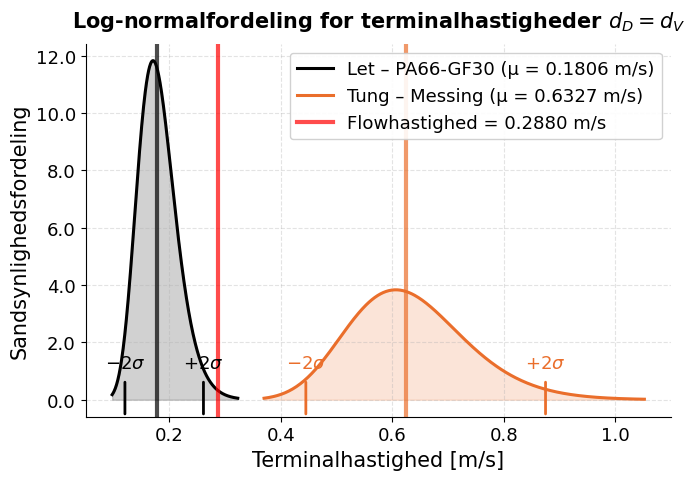

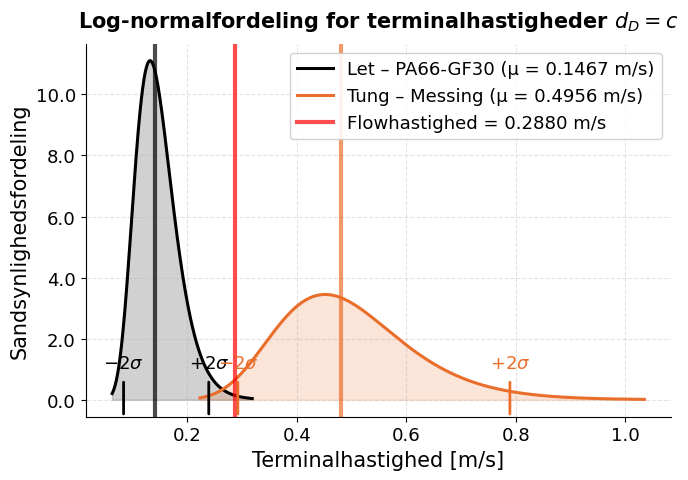

In [5]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "dV")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "dV")

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$",
    v_experiment=0.288,
)

df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "c")

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$",
    v_experiment=0.288,
)

# Renhed og udbytte (andel-baseret)

In [6]:
# === Renhed og udbytte (ANDEL-baseret) ===
# Beregnet ud fra den fittede log-normalfordeling af v_single (samme data som
# fordelingsplottene). En partikel synker til underflow hvis v_single > v_flow,
# ellers loftes den til overflow. Renhed og udbytte er ANDELE (areal under
# fordelingen), ikke masse. Renheden forudsaetter samme udgangsandel af hvert
# materiale; den reelle masse-renhed afhaenger af blandingsforholdet.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def renhed_udbytte(v_light, v_heavy, v_flow):
    """light loftes (overflow) hvis v < v_flow ; heavy synker (underflow) hvis v > v_flow."""
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    light_over = lognorm.cdf(v_flow, sL, 0, scL)   # let i overflow (korrekt)
    heavy_over = lognorm.cdf(v_flow, sH, 0, scH)    # tung i overflow (forkert)
    light_under = 1 - light_over                    # let i underflow (forkert)
    heavy_under = 1 - heavy_over                     # tung i underflow (korrekt)
    return {
        "Overflow renhed %":   100*light_over /(light_over + heavy_over),
        "Overflow udbytte %":  100*light_over,
        "Underflow renhed %":  100*heavy_under/(heavy_under + light_under),
        "Underflow udbytte %": 100*heavy_under,
    }

def vis(label, v_light, v_heavy, v_flow):
    r = renhed_udbytte(v_light, v_heavy, v_flow)
    print(f"{label}  (v_flow = {v_flow} m/s)")
    print(f"   Overflow  (let):   renhed {r['Overflow renhed %']:6.1f} %   udbytte {r['Overflow udbytte %']:6.1f} %")
    print(f"   Underflow (tung):  renhed {r['Underflow renhed %']:6.1f} %   udbytte {r['Underflow udbytte %']:6.1f} %")
    print()
    return r

# --- Grundfoss (PA66/Messing): en samlet blanding, begge diametre ---
for dD in ["c", "dV"]:
    vL = calculate(data_light, rho_p=rho_l, C=C, dD=dD)["v_single_m/s"].values
    vH = calculate(data_heavy, rho_p=rho_h, C=C, dD=dD)["v_single_m/s"].values
    vis(f"Grundfoss | d_D = {dD}", vL, vH, 0.288)


Grundfoss | d_D = c  (v_flow = 0.288 m/s)
   Overflow  (let):   renhed   98.4 %   udbytte   99.7 %
   Underflow (tung):  renhed   99.7 %   udbytte   98.4 %

Grundfoss | d_D = dV  (v_flow = 0.288 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte   99.5 %
   Underflow (tung):  renhed   99.5 %   udbytte  100.0 %



# Teoretisk optimal separation

In [7]:
# === Teoretisk optimal separation (andel-baseret) ===
# Finder den flowhastighed der MAKSIMERER det samlede udbytte (let op + tung ned).
# Dette er den teoretiske oevre graense givet fordelingernes overlap.
# Renhed og udbytte er andele, ikke masse.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def optimal_separation(v_light, v_heavy, n=4000):
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    lo = min(v_light.min(), v_heavy.min())
    hi = max(v_light.max(), v_heavy.max())
    flows = np.linspace(lo, hi, n)
    best = None
    for f in flows:
        light_over = lognorm.cdf(f, sL, 0, scL)      # let i overflow (udbytte)
        heavy_under = 1 - lognorm.cdf(f, sH, 0, scH)  # tung i underflow (udbytte)
        tot = light_over + heavy_under
        if best is None or tot > best[0]:
            heavy_over  = lognorm.cdf(f, sH, 0, scH)
            light_under = 1 - light_over
            ren_over  = light_over  / (light_over + heavy_over)
            ren_under = heavy_under / (heavy_under + light_under)
            best = (tot, f, light_over, heavy_under, ren_over, ren_under)
    _, f, lo_u, hu, ro, ru = best
    return {"v_optimal": f, "Overflow renhed %": 100*ro, "Overflow udbytte %": 100*lo_u,
            "Underflow renhed %": 100*ru, "Underflow udbytte %": 100*hu}

def vis_optimal(navn, v_light, v_heavy):
    r = optimal_separation(v_light, v_heavy)
    print(f"{navn}: optimal flowhastighed = {r['v_optimal']:.3f} m/s")
    print(f"   Overflow  (let):   renhed {r['Overflow renhed %']:5.1f} %   udbytte {r['Overflow udbytte %']:5.1f} %")
    print(f"   Underflow (tung):  renhed {r['Underflow renhed %']:5.1f} %   udbytte {r['Underflow udbytte %']:5.1f} %")
    print()
    return r

# Grundfoss: en samlet blanding (PA66-GF30 let, Messing tung)
vL = calculate(data_light, rho_p=rho_l, C=C, dD="c")["v_single_m/s"].values
vH = calculate(data_heavy, rho_p=rho_h, C=C, dD="c")["v_single_m/s"].values
vis_optimal("PA66-GF30/Messing | d_D = c", vL, vH)


PA66-GF30/Messing | d_D = c: optimal flowhastighed = 0.265 m/s
   Overflow  (let):   renhed  99.4 %   udbytte  99.3 %
   Underflow (tung):  renhed  99.3 %   udbytte  99.4 %



{'v_optimal': 0.2647094236843943,
 'Overflow renhed %': 99.35453685139689,
 'Overflow udbytte %': 99.31506515468658,
 'Underflow renhed %': 99.31533715841068,
 'Underflow udbytte %': 99.35479328181714}